In [1]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.3 MB/s eta 0:00:00


In [2]:
!pip install optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 6.2 MB/s eta 0:00:00


In [3]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [4]:
!unzip -q "HAM_CLEAN_SPLIT.zip" -d /content/dataset

In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

import optuna
from optuna.integration import TFKerasPruningCallback

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


In [6]:
CLEAN_ROOT = "/content/dataset/HAM_CLEAN_SPLIT"
TRAIN_DIR  = os.path.join(CLEAN_ROOT, "train")
VAL_DIR    = os.path.join(CLEAN_ROOT, "val")
TEST_DIR   = os.path.join(CLEAN_ROOT, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

Found 2984 files belonging to 7 classes.
Found 387 files belonging to 7 classes.
Found 390 files belonging to 7 classes.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [ ]:

def h_sigmoid(x):
    return tf.nn.relu6(x + 3.0) / 6.0

def h_swish(x):
    return x * h_sigmoid(x)

@tf.keras.utils.register_keras_serializable(package="Custom")
class CoordAttFast(layers.Layer):
   
    def __init__(self, reduction=64, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        c = int(input_shape[-1])
        mip = max(8, c // self.reduction)
        self.conv1  = layers.Conv2D(mip, 1, padding="same", use_bias=True)  
        self.conv_h = layers.Conv2D(c,   1, padding="same", use_bias=True)
        self.conv_w = layers.Conv2D(c,   1, padding="same", use_bias=True)
        super().build(input_shape)

    def call(self, x):
        h = tf.shape(x)[1]
        w = tf.shape(x)[2]

        x_h = tf.reduce_mean(x, axis=2, keepdims=True)  
        x_w = tf.reduce_mean(x, axis=1, keepdims=True)  
        x_w = tf.transpose(x_w, [0, 2, 1, 3])           

        y = tf.concat([x_h, x_w], axis=1)              
        y = h_swish(self.conv1(y))

        y_h, y_w = tf.split(y, [h, w], axis=1)
        y_w = tf.transpose(y_w, [0, 2, 1, 3])           

        a_h = tf.sigmoid(self.conv_h(y_h))             
        a_w = tf.sigmoid(self.conv_w(y_w))             
        return x * a_h * a_w

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg


In [8]:
def build_ca_model(dropout, reduction=64):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)

    # ✅ Insert YOUR CA
    x = CoordAttFast(reduction=reduction)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, outputs)


In [ ]:
def objective(trial):
    tf.keras.backend.clear_session()

    
    lr_head = trial.suggest_float("lr_head", 3e-5, 3e-3, log=True)
    lr_ft   = trial.suggest_float("lr_ft", 1e-6, 3e-4, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6, step=0.05)
    unfreeze_last = trial.suggest_categorical("unfreeze_last", [20,30, 40, 50,60])
    weight_decay = trial.suggest_categorical("weight_decay", [0.0, 1e-5, 1e-4])
    label_smoothing = trial.suggest_categorical("label_smoothing", [0.0, 0.05, 0.1])

    model = build_ca_model(dropout, reduction=64)

    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_head, weight_decay=weight_decay),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=6,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True),
             TFKerasPruningCallback(trial, "val_accuracy")
            
        ],
        verbose=0
    )

   
    base_model = next(
        l for l in model.layers
        if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
    )

    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_ft, weight_decay=weight_decay),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
            TFKerasPruningCallback(trial, "val_accuracy")
        ],
        verbose=0
    )

    return float(max(history.history["val_accuracy"]))


In [10]:
study_ca = optuna.create_study(direction="maximize")
study_ca.optimize(objective, n_trials=50)

print("CA Best Validation Accuracy:", study_ca.best_value)
print("CA Best Hyperparameters:")
for k, v in study_ca.best_params.items():
    print(k, ":", v)

[I 2026-02-27 16:52:37,261] A new study created in memory with name: no-name-e3701519-31d0-4e4d-8909-374e5fc2c55a


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 1 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 2 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 3 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported 

CA Best Validation Accuracy: 0.43410852551460266
CA Best Hyperparameters:
lr_head : 0.002050091384393143
lr_ft : 0.00015823928112402967
dropout : 0.4
unfreeze_last : 20
weight_decay : 0.0001
label_smoothing : 0.05


In [ ]:
best_params = study_ca.best_params
tf.keras.backend.clear_session()

final_model = build_ca_model(best_params["dropout"], reduction=64)
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=best_params["label_smoothing"])

ckpt_path = "mobilenetv2_ca_tuned_best.keras"


final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["lr_head"],
        weight_decay=best_params["weight_decay"]
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_fe = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history_fe = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_fe,
    verbose=1
)


base_model = next(
    l for l in final_model.layers
    if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
)

base_model.trainable = True
for layer in base_model.layers[:-best_params["unfreeze_last"]]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["lr_ft"],
        weight_decay=best_params["weight_decay"]
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history_ft = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 196ms/step - accuracy: 0.2444 - loss: 1.8551 - val_accuracy: 0.2506 - val_loss: 1.8298 - learning_rate: 0.0021
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4041 - loss: 1.5868 - val_accuracy: 0.3333 - val_loss: 1.7276 - learning_rate: 0.0021
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4287 - loss: 1.5094 - val_accuracy: 0.3230 - val_loss: 1.7283 - learning_rate: 0.0021
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4600 - loss: 1.4552 - val_accuracy: 0.3204 - val_loss: 1.7846 - learning_rate: 0.0021
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4932 - loss: 1.3838 - val_accuracy: 0.3566 - val_loss: 1.6630 - learning_rate: 6.1503e-04
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5011 - loss: 1.3546 - val_accuracy: 0.3385 - val_loss: 1.6916 - learning_rate: 6.1503e-04
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5247 - loss: 1.3141

In [ ]:

best_model = keras.models.load_model(
    ckpt_path,
    custom_objects={"CoordAttFast": CoordAttFast}
)

test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\nCA Tuned Test Accuracy: {test_acc:.4f}")



13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 501ms/step - accuracy: 0.4434 - loss: 1.5304

CA Tuned Test Accuracy: 0.4590


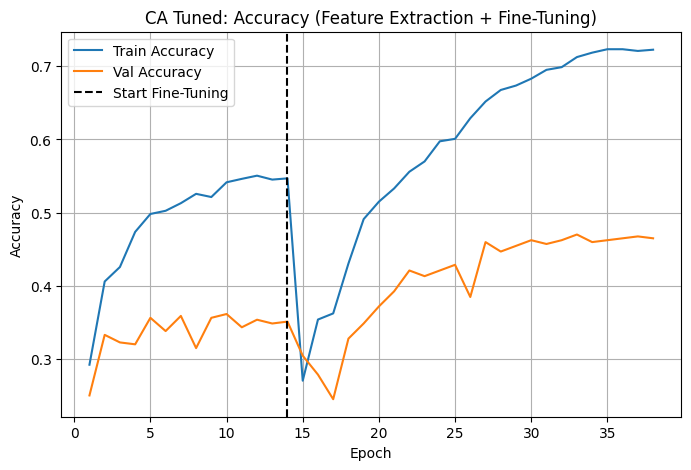

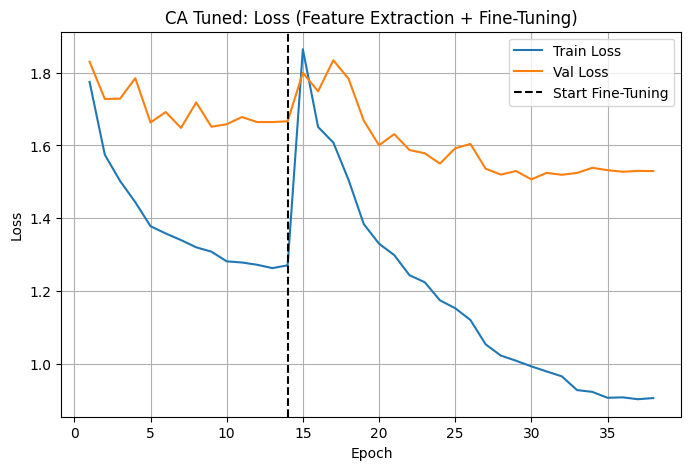

In [13]:
def combine_histories(h1, h2):
    combined = {}
    for key in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        combined[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return combined

combined = combine_histories(history_fe, history_ft)
epochs_total = range(1, len(combined["loss"]) + 1)
split_epoch = len(history_fe.history["loss"])

plt.figure(figsize=(8,5))
plt.plot(epochs_total, combined["accuracy"], label="Train Accuracy")
plt.plot(epochs_total, combined["val_accuracy"], label="Val Accuracy")
plt.axvline(split_epoch, linestyle="--", color="black", label="Start Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CA Tuned: Accuracy (Feature Extraction + Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_total, combined["loss"], label="Train Loss")
plt.plot(epochs_total, combined["val_loss"], label="Val Loss")
plt.axvline(split_epoch, linestyle="--", color="black", label="Start Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CA Tuned: Loss (Feature Extraction + Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
y_true, y_pred = [], []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, target_names=class_names))


Macro F1: 0.43195967204964875
              precision    recall  f1-score   support

       akiec       0.42      0.46      0.44        50
         bcc       0.47      0.48      0.48        75
         bkl       0.34      0.35      0.34        75
          df       0.29      0.11      0.16        18
         mel       0.43      0.48      0.45        75
          nv       0.68      0.56      0.61        75
        vasc       0.47      0.64      0.54        22

    accuracy                           0.46       390
   macro avg       0.44      0.44      0.43       390
weighted avg       0.46      0.46      0.46       390



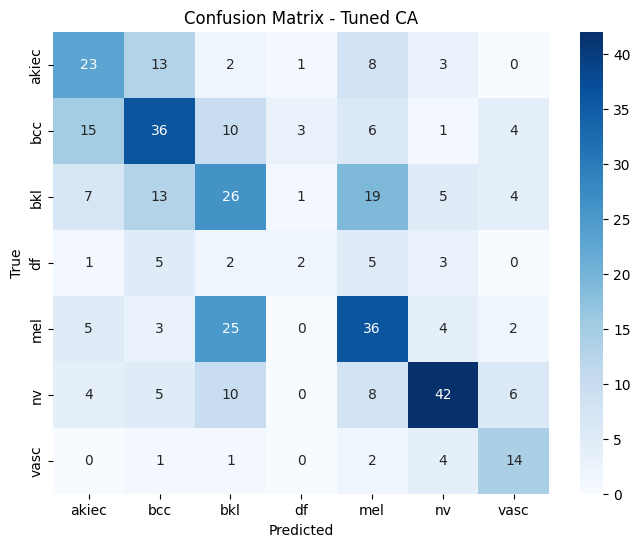

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Tuned CA")
plt.show()


In [16]:
specificity = []
for i in range(len(cm)):
    tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    spec = tn / (tn + fp + 1e-8)
    specificity.append(spec)

for cls, spec in zip(class_names, specificity):
    print(f"{cls} Specificity: {spec:.4f}")



akiec Specificity: 0.9059
bcc Specificity: 0.8730
bkl Specificity: 0.8413
df Specificity: 0.9866
mel Specificity: 0.8476
nv Specificity: 0.9365
vasc Specificity: 0.9565


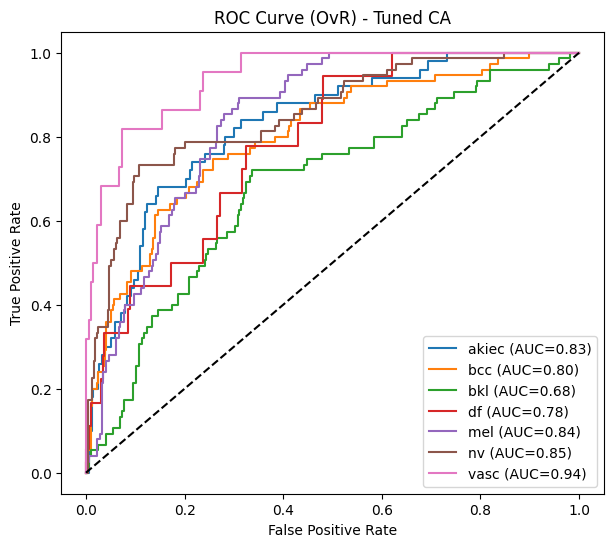

Macro Average AUC: 0.8188606582715537


In [17]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve (OvR) - Tuned CA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
print("Macro Average AUC:", macro_auc)

In [18]:
import optuna.visualization as vis
vis.plot_param_importances(study_ca)

In [19]:

vis.plot_optimization_history(study_ca)


In [20]:
vis.plot_parallel_coordinate(study_ca)

In [21]:
best_model.save("mobilenetv2_ca_tuned.keras")


In [22]:
best_model.save_weights("mobilenetv2_ca_tuned.weights.h5")